In [1]:
'''
Here in this data set,

We tested the sign inversion found in Fig 1 of Raynes, Y., Wylie, C.S., Sniegowski, P.D. and Weinreich, D.M., 2018. 
Sign of selection on mutation rate modifiers depends on population size. Proceedings of the National Academy of Sciences, 
115(13), pp.3422-3427.

Here we tried the equations developed in their paper using our parameters (10 upper modifier loci and 10 lower modifier loci,
both upper and lower modifer have the same mutation rate per site per generation compared to that in fitness loci. Note that 
in our other simulation that upper loci has a 5 times higher mutation rate compared to the lower loci. Other parameters are the
same as our original simulations.)

According to File 2.0 in the same folder, given an upper effect of a single modifer loci to be 90%, the sign transversion will
occur with a population size of 514 (but that is just assuming 1 modifer loci within the system), so here we simulated the 
mutation rate evolution under population size N = 300, 514 and 1K for 20K generations, to see whether the N = 514 can maintain
a realtive unchanged mutation rate.

The answer is no. With N = 1K, we still see mutation rate decay.

'''

'\nHere we assumed a diploid single locus, and we want to investigate the performance of different reproduction strategies on mutation rate evolution\nunder a diplod system. This simulation has been extended to 20KG and compared the mu evolution among different sexual frequencies. (RM)\n\nHere N = 2000 and assuming 1% mutations are beneficial. Assuming the effect of mutations within modifier loci are additive.\n\nHere this file plots the results of mitosis, and having RM every 1, 10, 100, 1K and 10K generations.\n\n\n\n'

In [1]:
from __future__ import division
import numpy as np
from scipy import stats
import scipy.spatial as spa
import numpy.random as rnd
import copy
import time
import pandas as pd
import math
import pickle
import seaborn as sns
import os

In [2]:
def get_data1(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_soma_mu_bene_mean = []
    total_soma_mu_bene_std = []

    total_soma_mu_dele_mean = []
    total_soma_mu_dele_std = []
    
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        soma_mu_bene_mean = []
        soma_mu_bene_std = []

        soma_mu_dele_mean = []
        soma_mu_dele_std = []
            
        
        fit_mean.extend(list(pd.Series(f.PopMeanFit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    
        soma_mu_bene_mean.extend(list(pd.Series(f.SomaMu_Bene_Mean,dtype=float)))
        soma_mu_bene_std.extend(list(pd.Series(f.SomaMu_Bene_Std,dtype=float)))

        soma_mu_dele_mean.extend(list(pd.Series(f.SomaMu_Dele_Mean,dtype=float)))
        soma_mu_dele_std.extend(list(pd.Series(f.SomaMu_Dele_Std,dtype=float)))
        
        
        
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_soma_mu_bene_mean.append(soma_mu_bene_mean)
        total_soma_mu_bene_std.append(soma_mu_bene_std)  

        total_soma_mu_dele_mean.append(soma_mu_dele_mean)
        total_soma_mu_dele_std.append(soma_mu_dele_std)
        
        
        
    return total_fit_mean, total_fit_std, total_soma_mu_bene_mean, total_soma_mu_bene_std, \
total_soma_mu_dele_mean, total_soma_mu_dele_std

## Simulating for 20K Generation

In [3]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20200622_Test of Mu Rate Evolution_1% Bene\Data\1. Mito_Same Mu for Upper and Lower Mod")

In [4]:
n20_fit_file = ['Fit_Mito_P2SN_N300_Bene01_MuEvo_200622.csv', 'Fit_Mito_P2SN_N514_Bene01_MuEvo_200622.csv', \
               'Fit_Mito_P2SN_N1K_Bene01_MuEvo_200622.csv']

n20 = get_data1(n20_fit_file)

n20_fit_mean =n20[0]
n20_fit_std = n20[1]

n20_sm_mu_bene_mean = n20[2]
n20_sm_mu_bene_std = n20[3]

n20_sm_mu_dele_mean = n20[4]
n20_sm_mu_dele_std = n20[5]

In [5]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 30})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(8)
    ax.spines['bottom'].set_linewidth(8)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')

In [6]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

In [7]:
generation_list = []

for i in range(20002):
    generation_list.append(i)
    
print(len(generation_list))

20002


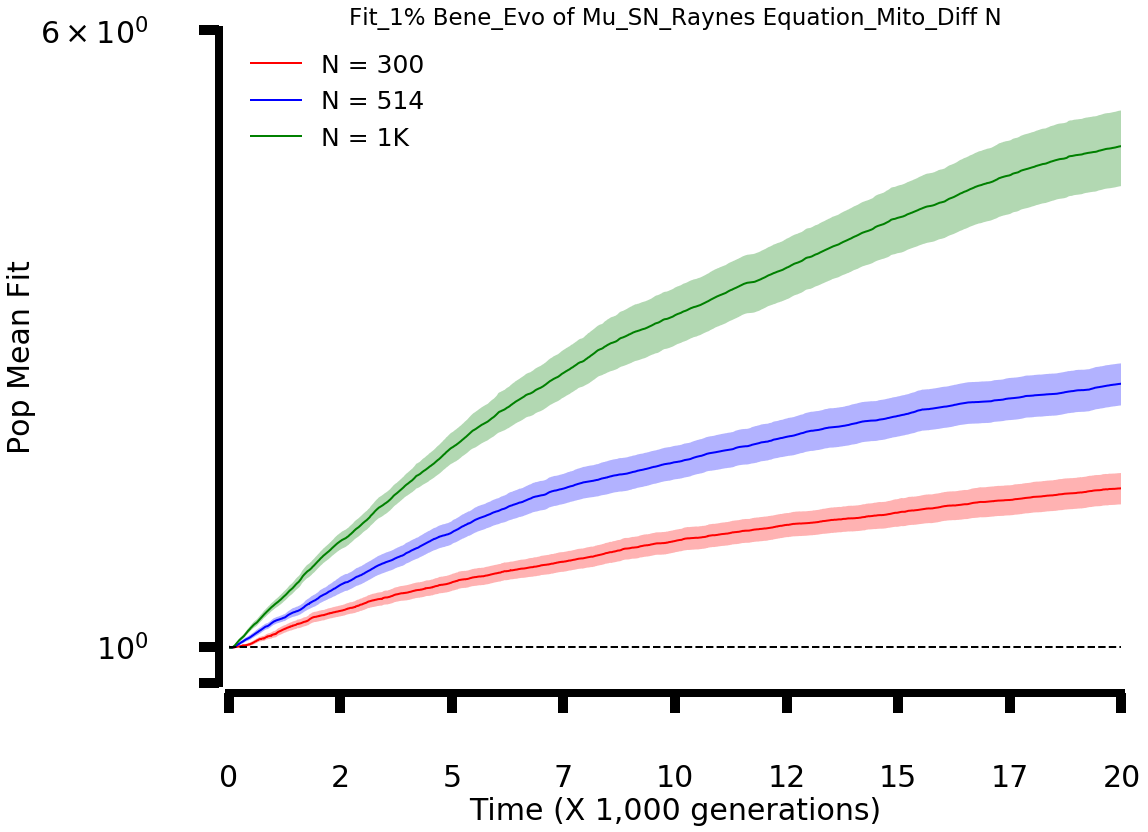

In [15]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,20*1000)

t = generation_list

a1 = n20_fit_mean[0]
error_a1 = list(1.98* np.array(n20_fit_std[0])/((100)**0.5))


a2 = n20_fit_mean[1]
error_a2 = list(1.98* np.array(n20_fit_std[1])/((100)**0.5))


a3 = n20_fit_mean[2]
error_a3 = list(1.98* np.array(n20_fit_std[2])/((100)**0.5))




ax.set_title('Fit_1% Bene_Evo of Mu_SN_Raynes Equation_Mito_Diff N', fontsize =23)
ax.set_xlabel('Time (X 1,000 generations)', fontsize =30)
ax.set_ylabel('Pop Mean Fit', fontsize =30)


# ax.semilogy(t, a, )

ax.set_yscale('log')


ax.plot(t,a1,'r', label = 'N = 300',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='r')

ax.plot(t,a2,'b', label = 'N = 514',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='b')


ax.plot(t,a3,'g', label = 'N = 1K',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='g')




plt.axhline(y=1, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

plt.legend(loc=2, frameon=False, prop={'size':25})

extraticks=[0.9, 6]
ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(0.9, 6)



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

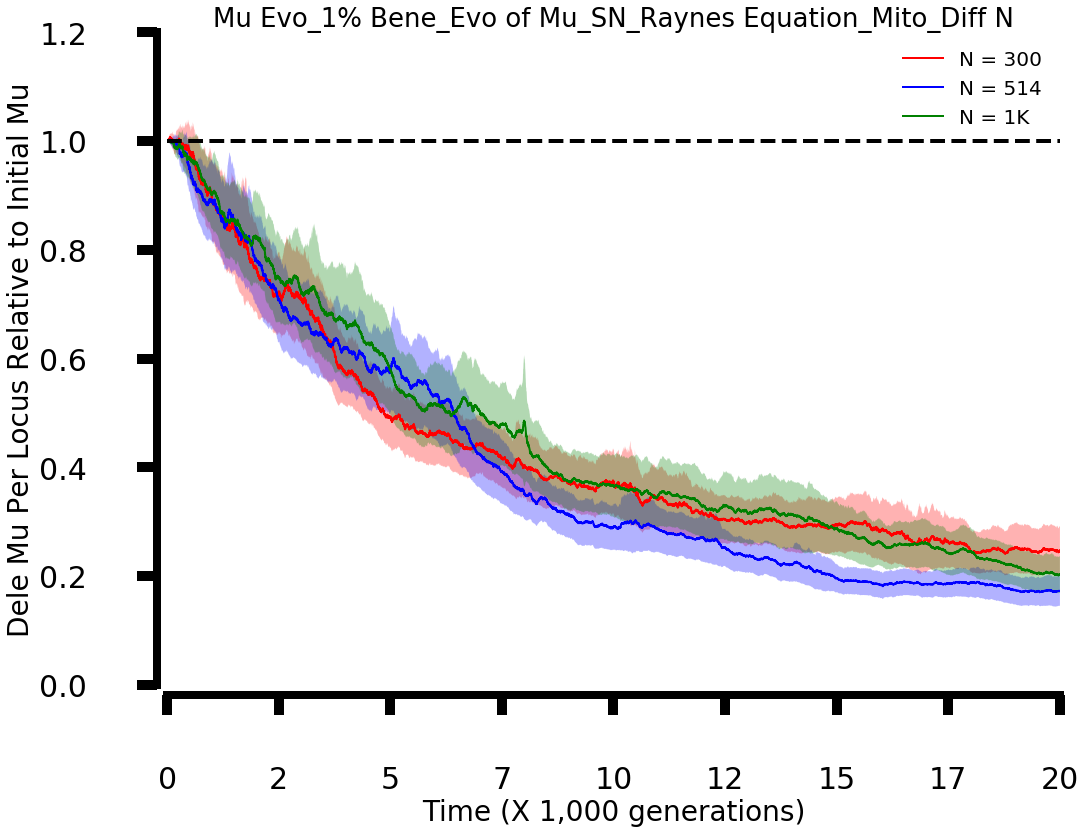

In [23]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,20*1000)
ax.set_ylim(0, 1.2)

t = generation_list

a1 = np.array(n20_sm_mu_dele_mean[0])/(0.1*2/45/(2*100))
error_a1 = 1.98* np.array(n20_sm_mu_dele_std[0])/((100)**0.5)/(0.1*2/45/(2*100))


a2 = np.array(n20_sm_mu_dele_mean[1])/(0.1*2/45/(2*100))
error_a2 = 1.98* np.array(n20_sm_mu_dele_std[1])/((100)**0.5)/(0.1*2/45/(2*100))


a3 = np.array(n20_sm_mu_dele_mean[2])/(0.1*2/45/(2*100))
error_a3 = 1.98* np.array(n20_sm_mu_dele_std[2])/((100)**0.5)/(0.1*2/45/(2*100))



ax.set_title('Mu Evo_1% Bene_Evo of Mu_SN_Raynes Equation_Mito_Diff N', fontsize =26)
ax.set_xlabel('Time (X 1,000 generations)', fontsize =28)
ax.set_ylabel('Dele Mu Per Locus Relative to Initial Mu', fontsize =28)



ax.plot(t,a1,'r', label = 'N = 300',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='r')

ax.plot(t,a2,'b', label = 'N = 514',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='b')


ax.plot(t,a3,'g', label = 'N = 1K',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='g')


plt.axhline(y= (0.1*2/45/(2*100))/(0.1*2/45/(2*100)), linewidth=4.0, color ='k',ls ='dashed')


ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

# extraticks=[0.1, 1.1]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)


plt.legend(loc=1, frameon=False, prop={'size':20})



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

### Check whether the Ctrl Loci have been mutation-fixed

In [10]:
import pickle

In [11]:
def read_file(file_name):
    with open(file_name, 'rb') as f:
        x = pickle.load(f)
        
    return x

In [12]:
def read_file_list(file_list):    
    
    total_x = []
    for i in file_list:
        with open(i, 'rb') as f:
            x = pickle.load(f)
            total_x.append(x)
    return total_x

In [13]:
sm_upper_file = ['Mito_P2SN_N300_Bene01_SM_Ctrl_Upper_200622', 
                'Mito_P2SN_N514_Bene01_SM_Ctrl_Upper_200622', \
                'Mito_P2SN_N1K_Bene01_SM_Ctrl_Upper_200622']

In [14]:
sm_lower_file = ['Mito_P2SN_N300_Bene01_SM_Ctrl_Lower_200622', 
                'Mito_P2SN_N514_Bene01_SM_Ctrl_Lower_200622', \
                'Mito_P2SN_N1K_Bene01_SM_Ctrl_Lower_200622']

In [15]:
sm_upper = read_file_list(sm_upper_file)
sm_lower = read_file_list(sm_lower_file)

In [16]:
def check_mut_fix(loci_array, fix_num):
    
    nRep = loci_array[0].shape[0]
    nLoci = loci_array[0].shape[2]
    
    fix_loci_mean = []
    fix_loci_std = []
    for i in loci_array:
        nInd = i.shape[1]
        fix_loci = np.sum(np.sum(i== fix_num,axis=1)==nInd,axis=1)
        fix_loci_mean.append(np.nanmean(fix_loci))
        fix_loci_std.append(np.nanstd(fix_loci))
    
    return fix_loci_mean, fix_loci_std

In [17]:
sm_upper_fix = check_mut_fix(sm_upper, 2)
sm_upper_fix 

([0.32, 0.2, 0.24],
 [0.6462197768561405, 0.4242640687119285, 0.5314132102234569])

In [18]:
sm_lower_fix = check_mut_fix(sm_lower, 2)
sm_lower_fix 

([0.43, 0.49, 0.47],
 [0.552358579185659, 0.4998999899979995, 0.5376802023508025])

In [19]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 20})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')

C:\Users\ustzh\Anaconda2\lib\site-packages\matplotlib\cbook\deprecation.py:107: MatplotlibDeprecationWarning: Passing one of 'on', 'true', 'off', 'false' as a boolean is deprecated; use an actual boolean (True/False) instead.
  warnings.warn(message, mplDeprecation, stacklevel=1)


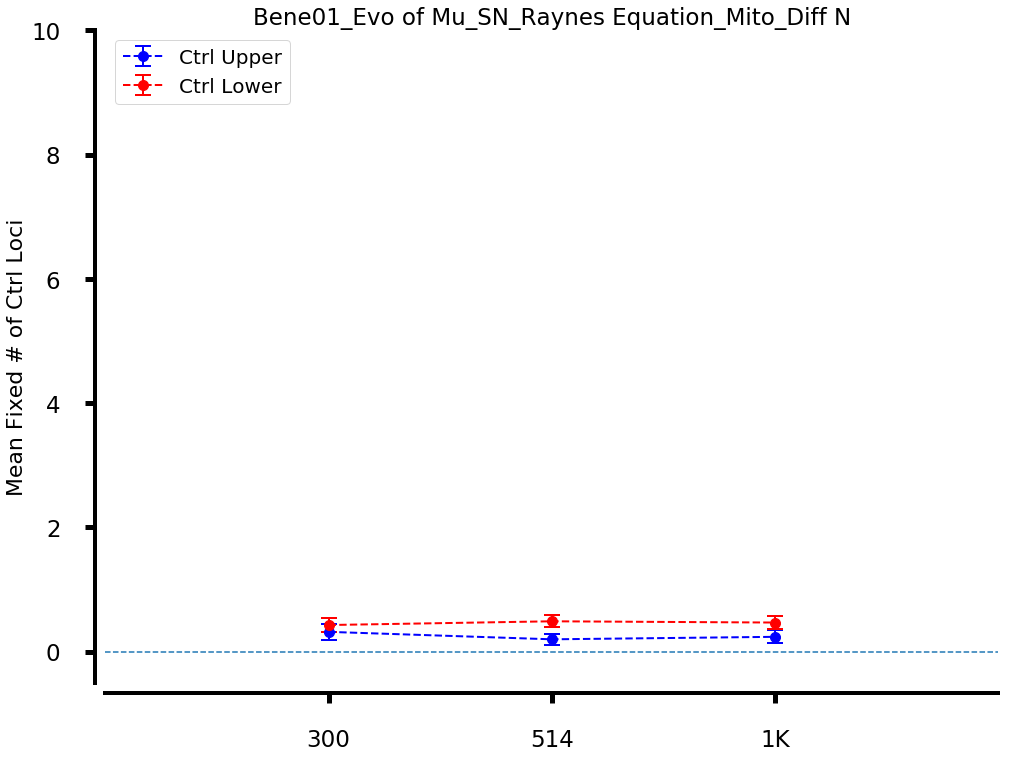

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)

mean1 = sm_upper_fix [0]
error_bar1 = 1.98*np.array(sm_upper_fix[1])/(100**0.5)

mean2 = sm_lower_fix [0]
error_bar2 = 1.98*np.array(sm_lower_fix[1])/(100**0.5)



plt.errorbar( xrange(3), mean1, yerr=error_bar1, label = 'Ctrl Upper', color = 'b', fmt='o', ls = '--', markersize =10, lw=2, capsize=8, capthick=2)
plt.errorbar( xrange(3), mean2, yerr=error_bar2, label = 'Ctrl Lower', color = 'r', fmt='o', ls = '--', markersize =10, lw=2, capsize=8, capthick=2)


plt.title('Bene01_Evo of Mu_SN_Raynes Equation_Mito_Diff N', fontsize =23)
plt.ylabel('Mean Fixed # of Ctrl Loci', fontsize =22)
plt.axhline(y=0, xmin=0, xmax=22, ls ='dashed')

 

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

x = range(3)
my_xticks = ['300', '514', '1K']
plt.xticks(x, my_xticks, rotation =0)

plt.tick_params(axis='both', labelsize=23)

plt.legend(loc='upper left')

# legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =15)
# frame = legend.get_frame()
# # frame.set_framecolor('black')
# frame.set_edgecolor('black')


plt.xlim(-1, 3)
plt.ylim(-0.5, 10)


plt.show()